# Demo 3: 使用 REFLECT 方法生成 AI2THOR 数据

本 demo 使用 REFLECT 框架的 `gen_data.py` 来生成 AI2THOR 模拟数据，确保生成的视频和数据与 REFLECT 框架保持一致。

## 特点

1. **使用 REFLECT 的稳定实现**: 直接调用 REFLECT 的 `run_data_gen` 函数
2. **任务定义与 REFLECT 一致**: 使用与 `reflect/main/tasks.json` 相同的任务配置格式
3. **数据保存位置**: 数据保存在 `craft/thor_tasks/` 目录下，参考 REFLECT 的目录结构
4. **支持两个示例任务**:
   - Task 1: makeCoffee (制作咖啡)
   - Task 2: boilWater (烧水)

## 目录结构

生成的数据将保存在:
```
craft/
└── thor_tasks/
    ├── makeCoffee/
    │   └── makeCoffee-1/
    │       ├── task.json          # 任务配置
    │       ├── events/            # AI2THOR events
    │       │   ├── step_1.pickle
    │       │   ├── step_2.pickle
    │       │   └── ...
    │       ├── ego_img/           # 图像帧
    │       │   ├── img_step_1.png
    │       │   ├── img_step_2.png
    │       │   └── ...
    │       ├── original-video.mp4 # 生成的视频
    │       ├── interact_actions.pickle
    │       └── nav_actions.pickle
    └── boilWater/
        └── boilWater-1/
            └── ... (相同结构)
```


In [1]:
"""
Demo 3: 使用 REFLECT 方法生成 AI2THOR 数据

本代码直接使用 REFLECT 框架的 gen_data.py 来生成数据，确保与 REFLECT 框架保持一致。
"""

import os
import sys
import json
from pathlib import Path
from typing import Dict, List

# 设置路径
CRAFT_ROOT = Path.cwd()
REFLECT_ROOT = CRAFT_ROOT.parent / "reflect"
REFLECT_MAIN_DIR = REFLECT_ROOT / "main"

print(f"CRAFT 根目录: {CRAFT_ROOT}")
print(f"REFLECT 根目录: {REFLECT_ROOT}")
print(f"REFLECT main 目录: {REFLECT_MAIN_DIR}")
print()

# 检查 REFLECT 是否可用
if not REFLECT_MAIN_DIR.exists():
    raise FileNotFoundError(
        f"REFLECT main 目录不存在: {REFLECT_MAIN_DIR}\n"
        "请确保 REFLECT 框架已安装或路径正确。"
    )

# 添加 REFLECT 路径到 sys.path
if str(REFLECT_MAIN_DIR) not in sys.path:
    sys.path.insert(0, str(REFLECT_MAIN_DIR))

# 导入 REFLECT 的模块
try:
    from gen_data import run_data_gen
    from constants import TASK_DICT as REFLECT_TASK_DICT
    print("✅ 成功导入 REFLECT 模块")
except ImportError as e:
    raise ImportError(
        f"无法导入 REFLECT 模块: {e}\n"
        "请确保 REFLECT 框架已正确安装。"
    )

print(f"✅ REFLECT TASK_DICT: {REFLECT_TASK_DICT}")
print()


CRAFT 根目录: /home/fdse/zzy/craft
REFLECT 根目录: /home/fdse/zzy/reflect
REFLECT main 目录: /home/fdse/zzy/reflect/main

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
✅ 成功导入 REFLECT 模块
✅ REFLECT TASK_DICT: {0: '', 1: 'boilWater', 2: 'toastBread', 3: 'cookEgg', 4: 'heatPotato', 5: 'makeCoffee', 6: 'waterPlant', 7: 'storeEgg', 8: 'makeSalad', 9: 'switchDevices', 10: 'warmWater'}



## 任务定义

定义两个示例任务，与 `reflect/main/tasks.json` 中的 Task 1 和 Task 2 保持一致：


In [2]:
# 任务定义 - 与 reflect/main/tasks.json 保持一致
# Task 1: makeCoffee (制作咖啡)
task_makeCoffee = {
    "name": "make coffee",
    "task_idx": 5,  # makeCoffee 的索引
    "num_samples": 1,
    "failure_injection": False,
    "folder_name": "makeCoffee-1",
    "scene": "FloorPlan16",
    "chosen_failure": "occupied",
    "gt_failure_reason": "The robot failed to put the mug inside the coffee machine because there was already a cup inside it, occupying the space.",
    "gt_failure_step": "00:51",
    "preactions": [
        "(dirty_obj, Mug)"
    ],
    "failure_injection_params": {
        "src_obj_type": "Cup",
        "target_obj_type": "CoffeeMachine",
        "disp_x": 0.0,
        "disp_z": 0.05,
        "disp_y": 0.02
    },
    "actions": [
        "(navigate_to_obj, Mug)",
        "(pick_up, Mug)",
        "(navigate_to_obj, Sink)",
        "(put_on, Mug, SinkBasin)",
        "(toggle_on, Faucet)",
        "(toggle_off, Faucet)",
        "(pick_up, Mug)",
        "(pour, Mug, Sink)",
        "(navigate_to_obj, CoffeeMachine)",
        "(put_in, Mug, CoffeeMachine)",
        "(toggle_on, CoffeeMachine)",
        "(toggle_off, CoffeeMachine)",
        "(pick_up, Mug)",
        "(put_on, Mug, CounterTop)"
    ],
    "success_condition": "a clean mug is filled with coffee and on top of the countertop."
}

# Task 2: boilWater (烧水)
task_boilWater = {
    "name": "boil water",
    "task_idx": 1,  # boilWater 的索引
    "num_samples": 1,
    "failure_injection": False,
    "folder_name": "boilWater-1",
    "scene": "FloorPlan1",
    "gt_failure_reason": "The robot did not pick up the pot from sink before moving to stove burner.",
    "gt_failure_step": [["00:31", "00:41"]],
    "actions": [
        "(navigate_to_obj, Pot)",
        "(pick_up, Pot)",
        "(navigate_to_obj, Sink)",
        "(put_in, Pot, Sink)",
        "(toggle_on, Faucet)",
        "(toggle_off, Faucet)",
        "(navigate_to_obj, StoveBurner-4)",
        "(put_on, Pot, StoveBurner-4)",
        "(toggle_on, StoveBurner-4)"
    ],
    "success_condition": "a pot is filled with water, the pot is on top of a stove burner that is turned on."
}

print("📋 任务定义:")
print(f"  Task 1: {task_makeCoffee['name']} (task_idx={task_makeCoffee['task_idx']}, folder={task_makeCoffee['folder_name']})")
print(f"  Task 2: {task_boilWater['name']} (task_idx={task_boilWater['task_idx']}, folder={task_boilWater['folder_name']})")
print()


📋 任务定义:
  Task 1: make coffee (task_idx=5, folder=makeCoffee-1)
  Task 2: boil water (task_idx=1, folder=boilWater-1)



## 数据生成函数

创建一个函数来使用 REFLECT 的方法生成数据，并确保数据保存在 craft 框架的目录下。


In [3]:
def generate_data_with_reflect(task: Dict, craft_root: Path = None) -> Dict:
    """
    使用 REFLECT 的 run_data_gen 生成 AI2THOR 数据
    
    Args:
        task: 任务配置字典（REFLECT 格式）
        craft_root: CRAFT 框架根目录，默认为当前目录
    
    Returns:
        包含生成数据信息的字典
    """
    import pickle
    import numpy as np
    
    if craft_root is None:
        craft_root = Path.cwd()
    
    print(f"\n{'='*80}")
    print(f"生成任务数据: {task['name']} (folder: {task['folder_name']})")
    print(f"{'='*80}")
    
    # 获取任务对应的目录名（从 TASK_DICT）
    task_name = REFLECT_TASK_DICT.get(task['task_idx'], 'unknown_task')
    print(f"任务名称: {task_name}")
    print(f"场景: {task['scene']}")
    print(f"动作数量: {len(task['actions'])}")
    print()
    
    # 切换到 CRAFT 根目录（REFLECT 的 run_data_gen 会在当前目录创建 thor_tasks）
    original_cwd = os.getcwd()
    try:
        os.chdir(str(craft_root))
        print(f"当前工作目录: {os.getcwd()}")
        
        # 调用 REFLECT 的 run_data_gen
        print("\\n[INFO] 调用 REFLECT 的 run_data_gen...")
        print("  这将使用 REFLECT 的稳定实现来生成数据")
        print("  数据将保存在: thor_tasks/{}/{}".format(task_name, task['folder_name']))
        print()
        
        # 运行数据生成
        run_data_gen(data_path=str(craft_root), task=task)
        
        print("\\n✅ REFLECT 数据生成完成！")
        
    finally:
        # 恢复原始工作目录
        os.chdir(original_cwd)
    
    # 构建数据路径
    data_path = craft_root / "thor_tasks" / task_name / task['folder_name']
    
    # 检查生成的文件
    task_json_path = data_path / "task.json"
    video_path = data_path / "original-video.mp4"
    events_dir = data_path / "events"
    ego_img_dir = data_path / "ego_img"
    
    result = {
        "task_name": task_name,
        "folder_name": task['folder_name'],
        "data_path": str(data_path),
        "task_json_path": str(task_json_path),
        "video_path": str(video_path),
        "events_dir": str(events_dir),
        "ego_img_dir": str(ego_img_dir),
        "success": False
    }
    
    # 验证生成的文件
    if task_json_path.exists():
        print(f"\\n✅ task.json 已生成: {task_json_path}")
        result["success"] = True
        
        # 读取 task.json 查看生成的任务信息
        with open(task_json_path, 'r') as f:
            generated_task = json.load(f)
            print(f"   生成的 specific_folder_name: {generated_task.get('specific_folder_name', 'N/A')}")
    else:
        print(f"\\n⚠️  task.json 未找到: {task_json_path}")
    
    if video_path.exists():
        video_size = video_path.stat().st_size / (1024 * 1024)  # MB
        print(f"✅ 视频已生成: {video_path} ({video_size:.2f} MB)")
    else:
        print(f"⚠️  视频未找到: {video_path}")
    
    if events_dir.exists():
        event_files = list(events_dir.glob("*.pickle"))
        print(f"✅ Events 目录: {len(event_files)} 个事件文件")
    else:
        print(f"⚠️  Events 目录不存在: {events_dir}")
    
    if ego_img_dir.exists():
        img_files = list(ego_img_dir.glob("*.png"))
        print(f"✅ Ego images 目录: {len(img_files)} 个图像文件")
    else:
        print(f"⚠️  Ego images 目录不存在: {ego_img_dir}")
    
    print()
    
    return result


In [9]:
# 选择要生成的任务
# 可以设置为 "makeCoffee", "boilWater", 或 "both"
TASK_TO_GENERATE = "boilWater"  # 修改这里来选择要生成的任务

results = {}

if TASK_TO_GENERATE in ["makeCoffee", "both"]:
    print("\\n" + "="*80)
    print("生成 Task 1: makeCoffee")
    print("="*80)
    result_makeCoffee = generate_data_with_reflect(task_makeCoffee, craft_root=CRAFT_ROOT)
    results["makeCoffee"] = result_makeCoffee

if TASK_TO_GENERATE in ["boilWater", "both"]:
    print("\\n" + "="*80)
    print("生成 Task 2: boilWater")
    print("="*80)
    result_boilWater = generate_data_with_reflect(task_boilWater, craft_root=CRAFT_ROOT)
    results["boilWater"] = result_boilWater

print("\\n" + "="*80)
print("生成总结")
print("="*80)
for task_name, result in results.items():
    status = "✅ 成功" if result.get("success", False) else "❌ 失败"
    print(f"{task_name}: {status}")
    if result.get("success"):
        print(f"  数据路径: {result['data_path']}")
        print(f"  视频路径: {result['video_path']}")
print("="*80)


\n================================================================================
生成 Task 2: boilWater

生成任务数据: boil water (folder: boilWater-1)
任务名称: boilWater
场景: FloorPlan1
动作数量: 9

当前工作目录: /home/fdse/zzy/craft
\n[INFO] 调用 REFLECT 的 run_data_gen...
  这将使用 REFLECT 的稳定实现来生成数据
  数据将保存在: thor_tasks/boilWater/boilWater-1

[INFO] Execute action: Navigate to Pot
[INFO] Execute action: Picking up Pot
[INFO] Execute action: Navigate to Sink
[INFO] Execute action: Putting Pot in Sink
The robot is holding: Pot|-01.22|+00.90|-02.36 Pot
[INFO] Execute action: Toggling on Faucet
[INFO] Execute action: Toggling off Faucet
[INFO] Execute action: Navigate to StoveBurner-4
[INFO] Execute action: Putting Pot on StoveBurner-4
The robot is not holding anything
[INFO] Execute action: Toggling on StoveBurner-4
[INFO] interact_actions: {18: 'Pick up pot', 25: 'Put pot inside sink', 28: 'Toggle on faucet', 31: 'Toggle off faucet', 41: 'Put pot on fourth stove burner', 44: 'Toggle on fourth stove burner'}
[

[rawvideo @ 0x6216c3946d80] Stream #0: not enough frames to estimate rate; consider increasing probesize


sounds:  {27: 'toggle-on-faucet.wav', 43: 'toggle-on-stoveburner.wav'}


OSError: MoviePy error: the file /home/fdse/zzy/craft/main/assets/sounds/toggle-on-faucet.wav could not be found!
Please check that you entered the correct path.

## 验证生成的数据

检查生成的数据是否正确，并显示一些统计信息。


In [5]:
def verify_generated_data(result: Dict):
    """验证生成的数据"""
    from pathlib import Path
    import re
    
    data_path = Path(result['data_path'])
    
    if not data_path.exists():
        print(f"❌ 数据目录不存在: {data_path}")
        return
    
    print(f"\\n验证数据: {data_path.name}")
    print("-" * 80)
    
    # 检查 task.json
    task_json_path = Path(result['task_json_path'])
    if task_json_path.exists():
        with open(task_json_path, 'r') as f:
            task_info = json.load(f)
        print(f"✅ task.json:")
        print(f"   任务名称: {task_info.get('name', 'N/A')}")
        print(f"   场景: {task_info.get('scene', 'N/A')}")
        print(f"   动作数量: {len(task_info.get('actions', []))}")
        print(f"   folder_name: {task_info.get('folder_name', 'N/A')}")
    
    # 检查 events
    events_dir = Path(result['events_dir'])
    if events_dir.exists():
        event_files = list(events_dir.glob("*.pickle"))
        # 按文件名中的数字排序
        def get_step_number(f):
            match = re.search(r'step_(\d+)', f.stem)
            return int(match.group(1)) if match else 0
        event_files = sorted(event_files, key=get_step_number)
        print(f"\\n✅ Events: {len(event_files)} 个文件")
        if event_files:
            print(f"   第一个: {event_files[0].name}")
            print(f"   最后一个: {event_files[-1].name}")
    
    # 检查 ego_img
    ego_img_dir = Path(result['ego_img_dir'])
    if ego_img_dir.exists():
        img_files = list(ego_img_dir.glob("*.png"))
        # 按文件名中的数字排序
        def get_img_step_number(f):
            match = re.search(r'img_step_(\d+)', f.stem)
            return int(match.group(1)) if match else 0
        img_files = sorted(img_files, key=get_img_step_number)
        print(f"\\n✅ Ego Images: {len(img_files)} 个文件")
        if img_files:
            print(f"   第一个: {img_files[0].name}")
            print(f"   最后一个: {img_files[-1].name}")
    
    # 检查视频
    video_path = Path(result['video_path'])
    if video_path.exists():
        video_size_mb = video_path.stat().st_size / (1024 * 1024)
        print(f"\\n✅ Video: {video_path.name} ({video_size_mb:.2f} MB)")
    else:
        print(f"\\n⚠️  Video 不存在: {video_path}")
    
    print()

# 验证所有生成的数据
for task_name, result in results.items():
    if result.get("success", False):
        verify_generated_data(result)


## 数据路径总结

生成的数据保存在以下位置，可以在后续的 CRAFT 框架中使用：


In [6]:
print("\\n" + "="*80)
print("数据路径总结")
print("="*80)
print()
print("生成的数据已保存在 CRAFT 框架的 thor_tasks 目录下：")
print()
for task_name, result in results.items():
    if result.get("success", False):
        print(f"{task_name}:")
        print(f"  完整路径: {result['data_path']}")
        print(f"  相对路径: thor_tasks/{result['task_name']}/{result['folder_name']}")
        print()

print("\\n可以在后续代码中使用这些路径来加载数据。")
print("="*80)


\n================================================================================
数据路径总结

生成的数据已保存在 CRAFT 框架的 thor_tasks 目录下：

\n可以在后续代码中使用这些路径来加载数据。


---

# CRAFT 框架完整流程执行

基于 Method.md 的框架思想，对生成的 makeCoffee 和 boilWater 任务执行完整的 CRAFT 失败检测流程。

## 流程概述

1. **数据加载** - 从生成的数据中加载 events 和任务信息
2. **场景图生成** - 构建结构化场景表示（Method.md Section 1）
3. **约束生成** - LLM 生成逻辑约束（Method.md Section 2）
4. **约束编译** - 编译为可执行 AST/DSL（Method.md Section 2.2）
5. **失败检测** - 使用可执行逻辑验证约束（Method.md Section 4）
6. **结果可视化** - 展示检测结果和关键信息


In [29]:
"""
CRAFT 框架完整流程执行
基于 Method.md 的框架思想
"""

import os
import sys
import json
import pickle
from pathlib import Path
from typing import Dict, List, Tuple, Set
import numpy as np

# 添加当前目录到 Python 路径（确保可以导入 craft 模块）
CRAFT_ROOT = Path.cwd()
print(f"当前工作目录: {CRAFT_ROOT}")

# 确保当前目录在 sys.path 中（但不在最前面，避免覆盖）
if str(CRAFT_ROOT) not in sys.path:
    sys.path.insert(0, str(CRAFT_ROOT))

# 检查 craft 模块是否存在
craft_module_path = CRAFT_ROOT / "__init__.py"
core_module_path = CRAFT_ROOT / "core" / "__init__.py"
print(f"CRAFT __init__.py: {craft_module_path.exists()}")
print(f"CORE __init__.py: {core_module_path.exists()}")

# 导入 CRAFT 模块（使用与 demo1 相同的导入方式）
CRAFT_AVAILABLE = False
try:
    # 方法1: 标准导入（假设 craft 已经安装在 Python 路径中）
    from craft.core import SceneGraph, Node, Edge
    from craft.reasoning import (
        LLMPrompter,
        ConstraintGenerator,
        FailureAnalyzer
    )
    CRAFT_AVAILABLE = True
    print("✅ CRAFT modules imported successfully (method 1)!")
except ImportError as e:
    print(f"⚠️  Method 1 failed: {e}")
    print("   Trying method 2: direct import from current directory...")
    try:
        # 方法2: 如果当前目录就是 craft，尝试安装后导入
        if (CRAFT_ROOT / "core" / "__init__.py").exists() and (CRAFT_ROOT / "setup.py").exists():
            print("   Found setup.py, trying to install CRAFT in development mode...")
            import subprocess
            try:
                # 尝试安装（非阻塞，如果失败就继续）
                result = subprocess.run(
                    [sys.executable, "-m", "pip", "install", "-e", "."],
                    cwd=str(CRAFT_ROOT),
                    capture_output=True,
                    timeout=10
                )
                if result.returncode == 0:
                    print("   ✅ Installed CRAFT in development mode")
                    # 重新尝试导入
                    from craft.core import SceneGraph, Node, Edge
                    from craft.reasoning import LLMPrompter, ConstraintGenerator, FailureAnalyzer
                    CRAFT_AVAILABLE = True
                    print("✅ CRAFT modules imported using method 2!")
                else:
                    raise ImportError("Installation failed")
            except Exception as install_error:
                print(f"   ⚠️  Installation failed or skipped: {install_error}")
                raise ImportError("Cannot install CRAFT")
        else:
            raise ImportError("Cannot find craft modules in current directory")
    except Exception as e2:
        print(f"⚠️  Method 2 failed: {e2}")
        print("   Trying method 3: direct file import...")
        try:
            # 方法3: 直接从文件导入（绕过包结构）
            # 这个方法直接从 .py 文件导入，避免包结构问题
            import importlib.util
            import types
            
            # 创建命名空间模块
            craft_pkg = types.ModuleType('craft')
            craft_core_pkg = types.ModuleType('craft.core')
            craft_reasoning_pkg = types.ModuleType('craft.reasoning')
            sys.modules['craft'] = craft_pkg
            sys.modules['craft.core'] = craft_core_pkg
            sys.modules['craft.reasoning'] = craft_reasoning_pkg
            
            # 导入 scene_graph
            scene_graph_path = CRAFT_ROOT / "core" / "scene_graph.py"
            spec = importlib.util.spec_from_file_location("craft.core.scene_graph", scene_graph_path)
            scene_graph_module = importlib.util.module_from_spec(spec)
            scene_graph_module.__package__ = "craft.core"
            spec.loader.exec_module(scene_graph_module)
            sys.modules['craft.core.scene_graph'] = scene_graph_module
            
            # 从 scene_graph 模块获取类
            SceneGraph = scene_graph_module.SceneGraph
            Node = scene_graph_module.Node
            Edge = scene_graph_module.Edge
            
            # 导入 reasoning 子模块（需要按依赖顺序）
            # 先导入 llm_prompter（通常没有依赖）
            llm_prompter_path = CRAFT_ROOT / "reasoning" / "llm_prompter.py"
            spec = importlib.util.spec_from_file_location("craft.reasoning.llm_prompter", llm_prompter_path)
            llm_prompter_module = importlib.util.module_from_spec(spec)
            llm_prompter_module.__package__ = "craft.reasoning"
            spec.loader.exec_module(llm_prompter_module)
            sys.modules['craft.reasoning.llm_prompter'] = llm_prompter_module
            LLMPrompter = llm_prompter_module.LLMPrompter
            
            # 导入 constraint_generator
            constraint_gen_path = CRAFT_ROOT / "reasoning" / "constraint_generator.py"
            spec = importlib.util.spec_from_file_location("craft.reasoning.constraint_generator", constraint_gen_path)
            constraint_gen_module = importlib.util.module_from_spec(spec)
            constraint_gen_module.__package__ = "craft.reasoning"
            # 注入依赖
            constraint_gen_module.LLMPrompter = LLMPrompter
            spec.loader.exec_module(constraint_gen_module)
            sys.modules['craft.reasoning.constraint_generator'] = constraint_gen_module
            ConstraintGenerator = constraint_gen_module.ConstraintGenerator
            
            # 导入 failure_analyzer
            failure_analyzer_path = CRAFT_ROOT / "reasoning" / "failure_analyzer.py"
            spec = importlib.util.spec_from_file_location("craft.reasoning.failure_analyzer", failure_analyzer_path)
            failure_analyzer_module = importlib.util.module_from_spec(spec)
            failure_analyzer_module.__package__ = "craft.reasoning"
            spec.loader.exec_module(failure_analyzer_module)
            sys.modules['craft.reasoning.failure_analyzer'] = failure_analyzer_module
            FailureAnalyzer = failure_analyzer_module.FailureAnalyzer
            
            CRAFT_AVAILABLE = True
            print("✅ CRAFT modules imported using method 3!")
        except Exception as e3:
            print(f"⚠️  Method 3 failed: {e3}")
            import traceback
            traceback.print_exc()
            print("   Trying method 4: adding parent directory...")
            try:
                # 方法4: 添加父目录到路径
                parent_dir = CRAFT_ROOT.parent
                if (parent_dir / "craft" / "core" / "__init__.py").exists():
                    if str(parent_dir) not in sys.path:
                        sys.path.insert(0, str(parent_dir))
                    from craft.core import SceneGraph, Node, Edge
                    from craft.reasoning import LLMPrompter, ConstraintGenerator, FailureAnalyzer
                    CRAFT_AVAILABLE = True
                    print("✅ CRAFT modules imported using method 4!")
                else:
                    raise ImportError("Cannot find craft in parent directory")
            except Exception as e4:
                print(f"❌ All import methods failed. Last error: {e4}")
                print("   Some features may not work.")
                print(f"   Current directory: {CRAFT_ROOT}")
                print(f"   Please try installing CRAFT with: pip install -e .")
                CRAFT_AVAILABLE = False

# LLM API 配置（使用 demo1 中的配置）
API_KEY = "sk-wJJVkr6BUx8LruNeHNUCdmE1ARiB4qpLcdHHr3p4zVZTt8Fr"
POLOAPI_BASE_URL = "https://poloai.top/v1"

print("="*80)
print("CRAFT 框架初始化")
print("="*80)
print(f"CRAFT 模块可用: {'✅' if CRAFT_AVAILABLE else '❌'}")
print()

# 初始化 LLM Prompter
if CRAFT_AVAILABLE:
    try:
        llm_prompter = LLMPrompter(
            gpt_version="gpt-3.5-turbo",
            api_key=API_KEY,
            base_url=POLOAPI_BASE_URL
        )
        print("✅ LLM Prompter 初始化成功")
    except Exception as e:
        print(f"⚠️  LLM Prompter 初始化失败: {e}")
        llm_prompter = None
else:
    llm_prompter = None

print()


当前工作目录: /home/fdse/zzy/craft
CRAFT __init__.py: True
CORE __init__.py: True
✅ CRAFT modules imported successfully (method 1)!
CRAFT 框架初始化
CRAFT 模块可用: ✅

✅ LLM Prompter 初始化成功



## Step 1: 数据加载

从生成的数据中加载 events 和任务信息。


In [28]:
def load_task_data(data_path: str) -> Dict:
    """
    从生成的数据目录加载任务数据
    
    Returns:
        包含 events, task_info, action_results 的字典
    """
    data_dir = Path(data_path)
    
    # 加载 task.json
    task_json_path = data_dir / "task.json"
    if not task_json_path.exists():
        raise FileNotFoundError(f"task.json not found: {task_json_path}")
    
    with open(task_json_path, 'r') as f:
        task_info = json.load(f)
    
    # 加载 events
    events_dir = data_dir / "events"
    events = []
    if events_dir.exists():
        event_files = sorted(events_dir.glob("*.pickle"), 
                           key=lambda x: int(x.stem.split('_')[1]))
        for event_file in event_files:
            with open(event_file, 'rb') as f:
                events.append(pickle.load(f))
        print(f"✅ 加载了 {len(events)} 个 events")
    else:
        print(f"⚠️  Events 目录不存在: {events_dir}")
    
    # 构建 action_results
    action_results = []
    actions = task_info.get('actions', [])
    for i, action_str in enumerate(actions):
        action_results.append({
            'action': action_str,
            'status': 'SUCCESS',
            'step': i + 1
        })
    
    return {
        'events': events,
        'task_info': task_info,
        'action_results': action_results,
        'data_path': str(data_dir)
    }

# 加载 makeCoffee 和 boilWater 的数据
print("="*80)
print("Step 1: 数据加载")
print("="*80)

# 从之前生成的数据中加载
makeCoffee_data_path = CRAFT_ROOT / "thor_tasks" / "makeCoffee" / "makeCoffee-1"
boilWater_data_path = CRAFT_ROOT / "thor_tasks" / "boilWater" / "boilWater-1"

task_data = {}

if makeCoffee_data_path.exists():
    print(f"\n📂 加载 makeCoffee 数据: {makeCoffee_data_path}")
    task_data['makeCoffee'] = load_task_data(str(makeCoffee_data_path))
    print(f"   任务: {task_data['makeCoffee']['task_info'].get('name', 'N/A')}")
    print(f"   场景: {task_data['makeCoffee']['task_info'].get('scene', 'N/A')}")
    print(f"   动作数: {len(task_data['makeCoffee']['action_results'])}")
else:
    print(f"⚠️  makeCoffee 数据不存在: {makeCoffee_data_path}")

if boilWater_data_path.exists():
    print(f"\n📂 加载 boilWater 数据: {boilWater_data_path}")
    task_data['boilWater'] = load_task_data(str(boilWater_data_path))
    print(f"   任务: {task_data['boilWater']['task_info'].get('name', 'N/A')}")
    print(f"   场景: {task_data['boilWater']['task_info'].get('scene', 'N/A')}")
    print(f"   动作数: {len(task_data['boilWater']['action_results'])}")
else:
    print(f"⚠️  boilWater 数据不存在: {boilWater_data_path}")

print(f"\n✅ 数据加载完成！已加载 {len(task_data)} 个任务")


Step 1: 数据加载

📂 加载 makeCoffee 数据: /home/fdse/zzy/craft/thor_tasks/makeCoffee/makeCoffee-1
✅ 加载了 81 个 events
   任务: make coffee
   场景: FloorPlan16
   动作数: 14

📂 加载 boilWater 数据: /home/fdse/zzy/craft/thor_tasks/boilWater/boilWater-1
✅ 加载了 46 个 events
   任务: boil water
   场景: FloorPlan1
   动作数: 9

✅ 数据加载完成！已加载 2 个任务


## Step 2: 场景图生成

从 AI2THOR events 生成初始和最终场景图。


In [30]:
def extract_task_relevant_objects(task_info: Dict) -> Set[str]:
    """
    从任务信息中提取与任务相关的对象名称
    
    Args:
        task_info: 任务信息字典，包含 actions 和 success_condition
    
    Returns:
        相关对象名称的集合
    """
    relevant_objects = set()
    
    # 从 actions 中提取对象
    actions = task_info.get('actions', [])
    for action_str in actions:
        # 解析动作字符串，例如: "(pick_up, Mug)" 或 "(put_in, Mug, CoffeeMachine)"
        import re
        # 提取括号内的参数
        matches = re.findall(r'\(([^)]+)\)', action_str)
        for match in matches:
            parts = [p.strip() for p in match.split(',')]
            # 跳过第一个（动作类型），提取后面的对象名
            for obj_name in parts[1:]:
                if obj_name:
                    relevant_objects.add(obj_name)
    
    # 从 success_condition 中提取对象
    success_condition = task_info.get('success_condition', '')
    if success_condition:
        # 提取大写开头的单词（通常是对象名）
        obj_matches = re.findall(r'\b([A-Z][a-zA-Z]+)\b', success_condition)
        relevant_objects.update(obj_matches)
    
    # 从 preactions 中提取对象
    preactions = task_info.get('preactions', [])
    for preaction in preactions:
        matches = re.findall(r'\(([^)]+)\)', preaction)
        for match in matches:
            parts = [p.strip() for p in match.split(',')]
            for obj_name in parts[1:]:
                if obj_name:
                    relevant_objects.add(obj_name)
    
    return relevant_objects


def extract_task_relevant_subgraph(full_scene_graph: SceneGraph, task_info: Dict) -> SceneGraph:
    """
    从完整场景图中裁剪出与当前子任务相关的最小子图
    
    Args:
        full_scene_graph: 完整的场景图
        task_info: 任务信息字典
    
    Returns:
        裁剪后的最小子图，只包含与任务相关的节点和边
    """
    # 提取任务相关对象
    relevant_object_names = extract_task_relevant_objects(task_info)
    
    # 创建子图
    subgraph = SceneGraph()
    
    # 查找相关节点（支持部分匹配，因为对象名可能有变体）
    relevant_nodes = []
    for node in full_scene_graph.nodes:
        # 精确匹配
        if node.name in relevant_object_names:
            relevant_nodes.append(node)
            continue
        
        # 部分匹配（对象类型匹配）
        for obj_name in relevant_object_names:
            if obj_name.lower() in node.name.lower() or node.name.lower() in obj_name.lower():
                relevant_nodes.append(node)
                break
            # 检查对象类型
            if obj_name.lower() in node.object_type.lower() or node.object_type.lower() in obj_name.lower():
                relevant_nodes.append(node)
                break
    
    # 添加相关节点到子图
    for node in relevant_nodes:
        subgraph.add_node(node)
    
    # 添加相关边（只保留两个端点都在子图中的边）
    for (start_name, end_name), edge in full_scene_graph.edges.items():
        start_node = subgraph.get_node(start_name)
        end_node = subgraph.get_node(end_name)
        
        if start_node and end_node:
            # 两个节点都在子图中，添加边
            subgraph.add_edge(edge)
        elif start_node or end_node:
            # 至少一个节点在子图中，也添加边（保留与相关对象的直接关系）
            if start_node:
                # 如果终点不在子图中，尝试添加终点节点
                end_node_in_full = full_scene_graph.get_node(end_name)
                if end_node_in_full:
                    subgraph.add_node(end_node_in_full)
                    subgraph.add_edge(edge)
            elif end_node:
                # 如果起点不在子图中，尝试添加起点节点
                start_node_in_full = full_scene_graph.get_node(start_name)
                if start_node_in_full:
                    subgraph.add_node(start_node_in_full)
                    subgraph.add_edge(edge)
    
    return subgraph


def generate_scene_graph_from_event(event, task_info: Dict) -> SceneGraph:
    """
    从 AI2THOR event 生成场景图
    """
    if not CRAFT_AVAILABLE:
        raise RuntimeError("CRAFT modules not available")
    
    sg = SceneGraph()
    
    # 从 event.metadata 中提取对象信息
    if hasattr(event, 'metadata') and event.metadata:
        objects = event.metadata.get('objects', [])
        
        for obj in objects:
            # 创建节点
            node = Node(
                name=obj.get('name', 'unknown'),
                object_type=obj.get('objectType', 'Unknown'),
                state=obj.get('isFilled', False) and 'filled' or (obj.get('isOpen', False) and 'open' or 'closed'),
                position=tuple(obj.get('position', {}).values()) if isinstance(obj.get('position'), dict) else None,
                attributes={
                    'isFilled': obj.get('isFilled', False),
                    'isOpen': obj.get('isOpen', False),
                    'isToggled': obj.get('isToggledOn', False),
                    'isPickedUp': obj.get('isPickedUp', False),
                }
            )
            sg.add_node(node)
        
        # 添加关系边（需要在所有节点添加后再添加边）
        for obj in objects:
            node = sg.get_node(obj.get('name', 'unknown'))
            if not node:
                continue
            
            # 如果被拿起，创建与机器人的关系
            if obj.get('isPickedUp', False):
                robot_node = sg.get_node("Robot")
                if not robot_node:
                    robot_node = Node(name="Robot", object_type="Robot")
                    sg.add_node(robot_node)
                sg.add_edge(Edge(robot_node, node, "holding"))
            
            # 检查容器关系（parent-child relationships）
            if obj.get('parentReceptacles'):
                for parent_id in obj.get('parentReceptacles', []):
                    # 查找父容器对象
                    for other_obj in objects:
                        if other_obj.get('objectId') == parent_id:
                            parent_node = sg.get_node(other_obj.get('name', 'unknown'))
                            if parent_node:
                                sg.add_edge(Edge(node, parent_node, "inside"))
                            break
    
    return sg

# 为每个任务生成初始和最终场景图
print("="*80)
print("Step 2: 场景图生成")
print("="*80)

scene_graphs = {}

for task_name, data in task_data.items():
    if not data.get('events'):
        print(f"\n⚠️  {task_name}: 没有 events，跳过场景图生成")
        continue
    
    print(f"\n📊 生成 {task_name} 的场景图...")
    events = data['events']
    task_info = data['task_info']
    
    # 生成完整场景图
    initial_sg_full = generate_scene_graph_from_event(events[0], task_info)
    final_sg_full = generate_scene_graph_from_event(events[-1], task_info)
    
    print(f"   完整初始场景图: {len(initial_sg_full.nodes)} 个节点, {len(initial_sg_full.edges)} 条边")
    print(f"   完整最终场景图: {len(final_sg_full.nodes)} 个节点, {len(final_sg_full.edges)} 条边")
    
    # 裁剪出任务相关的子图
    initial_sg = extract_task_relevant_subgraph(initial_sg_full, task_info)
    final_sg = extract_task_relevant_subgraph(final_sg_full, task_info)
    
    print(f"   裁剪后初始场景图: {len(initial_sg.nodes)} 个节点, {len(initial_sg.edges)} 条边")
    print(f"   裁剪后最终场景图: {len(final_sg.nodes)} 个节点, {len(final_sg.edges)} 条边")
    
    # 显示相关对象
    relevant_objects = extract_task_relevant_objects(task_info)
    print(f"   任务相关对象: {sorted(relevant_objects)}")
    
    scene_graphs[task_name] = {
        'initial': initial_sg,
        'final': final_sg
    }
    
    # 保存到 data 中
    data['initial_sg'] = initial_sg
    data['final_sg'] = final_sg

print(f"\n✅ 场景图生成完成！已生成 {len(scene_graphs)} 个任务的场景图")


Step 2: 场景图生成

📊 生成 makeCoffee 的场景图...
   完整初始场景图: 90 个节点, 36 条边
   完整最终场景图: 90 个节点, 36 条边
   裁剪后初始场景图: 29 个节点, 26 条边
   裁剪后最终场景图: 29 个节点, 26 条边
   任务相关对象: ['CoffeeMachine', 'CounterTop', 'Faucet', 'Mug', 'Sink', 'SinkBasin']

📊 生成 boilWater 的场景图...
   完整初始场景图: 77 个节点, 38 条边
   完整最终场景图: 77 个节点, 38 条边
   裁剪后初始场景图: 12 个节点, 4 条边
   裁剪后最终场景图: 12 个节点, 4 条边
   任务相关对象: ['Faucet', 'Pot', 'Sink', 'StoveBurner-4']

✅ 场景图生成完成！已生成 2 个任务的场景图


## Step 3: 约束生成 (LLM)

使用 LLM 为每个任务生成逻辑约束。


In [41]:
# 约束生成
if not CRAFT_AVAILABLE or llm_prompter is None:
    print("⚠️  LLM Prompter 不可用，跳过约束生成")
    constraints_data = {}
else:
    print("="*80)
    print("Step 3: 约束生成 (LLM)")
    print("="*80)
    
    from craft.reasoning import ConstraintGenerator
    
    constraint_generator = ConstraintGenerator(llm_prompter)
    constraints_data = {}
    
    for task_name, data in task_data.items():
        if 'final_sg' not in data:
            print(f"\n⚠️  {task_name}: 没有场景图，跳过约束生成")
            continue
        
        print(f"\n🤖 为 {task_name} 生成约束...")
        task_info = data['task_info']
        final_sg = data['final_sg']
        
        # 生成约束（改进：要求生成动作级约束）
        try:
            # 改进提示：要求 LLM 为每个动作生成 pre/post 约束
            # 这里我们仍然使用现有的 generate_constraints，但会在后续步骤中
            # 将约束绑定到具体动作
            constraints = constraint_generator.generate_constraints(
                scene_graph=final_sg,
                task_info=task_info,
                goal=task_info.get('success_condition', '')
            )
            
            # 将约束绑定到具体动作（改进版：更精确的绑定逻辑）
            # 从任务信息中提取动作列表
            actions = task_info.get('actions', [])
            action_bound_constraints = []
            
            for constraint in constraints:
                constraint_desc = constraint.get('description', '').lower()
                constraint_type = constraint.get('type', 'unknown')
                
                # 改进的绑定逻辑：从约束描述中提取动作关键词和对象
                bound_action = None
                action_index = None
                
                # 提取约束中提到的对象
                import re
                obj_matches = re.findall(r'\b([A-Z][a-zA-Z]+)\b', constraint.get('description', ''))
                
                # 尝试匹配动作
                for idx, action_str in enumerate(actions):
                    action_lower = action_str.lower()
                    action_parts = [p.strip() for p in action_str.replace('(', '').replace(')', '').split(',')]
                    action_type = action_parts[0].lower() if action_parts else ''
                    
                    # 检查约束描述是否与动作相关
                    # 1. 检查动作类型是否在描述中（例如 "put_in", "fill", "place_on"）
                    action_keywords = {
                        'put_in': ['put', 'insert', 'inside', 'into'],
                        'put_on': ['put', 'place', 'on', 'top'],
                        'pick_up': ['pick', 'up', 'grab', 'take'],
                        'fill': ['fill', 'filled'],
                        'toggle_on': ['toggle', 'turn', 'on'],
                        'toggle_off': ['toggle', 'turn', 'off'],
                        'navigate_to_obj': ['navigate', 'move', 'to']
                    }
                    
                    matches_action_type = False
                    for keyword, synonyms in action_keywords.items():
                        if keyword in action_type:
                            matches_action_type = any(syn in constraint_desc for syn in synonyms)
                            if matches_action_type:
                                break
                    
                    # 2. 检查动作参数中的对象是否在约束描述中
                    matches_objects = False
                    if len(action_parts) > 1:
                        action_objects = [p.strip() for p in action_parts[1:]]
                        matches_objects = any(
                            obj.lower() in constraint_desc or constraint_desc.find(obj.lower()) != -1
                            for obj in action_objects
                            for obj_match in obj_matches
                            if obj.lower() in obj_match.lower() or obj_match.lower() in obj.lower()
                        )
                    
                    # 如果匹配，绑定到该动作
                    if matches_action_type or matches_objects:
                        bound_action = action_str
                        action_index = idx
                        break
                
                # 添加动作绑定信息
                constraint['bound_action'] = bound_action
                constraint['action_index'] = action_index
                constraint['action'] = bound_action.split(',')[0].replace('(', '').strip() if bound_action else None
                constraint['object'] = bound_action.split(',')[1].strip() if bound_action and ',' in bound_action else None
                constraint['target'] = bound_action.split(',')[2].strip() if bound_action and bound_action.count(',') >= 2 else None
                
                action_bound_constraints.append(constraint)
            
            constraints = action_bound_constraints
            
            print(f"   ✅ 生成了 {len(constraints) if constraints else 0} 个约束")
            if constraints:
                for i, constraint in enumerate(constraints[:3], 1):  # 只显示前3个
                    print(f"      {i}. {constraint.get('type', 'unknown')}: {constraint.get('description', 'N/A')[:60]}...")
            
            constraints_data[task_name] = constraints
            data['constraints'] = constraints
            
        except Exception as e:
            print(f"   ❌ 约束生成失败: {e}")
            constraints_data[task_name] = []
            data['constraints'] = []
    
    print(f"\n✅ 约束生成完成！已为 {len(constraints_data)} 个任务生成约束")


Step 3: 约束生成 (LLM)

🤖 为 makeCoffee 生成约束...
   ✅ 生成了 2 个约束
      1. precondition: Coffee machine must be empty before inserting mug...
      2. goal: A clean mug is filled with coffee and on top of the countert...

🤖 为 boilWater 生成约束...
   ✅ 生成了 8 个约束
      1. precondition: Pot must be empty before filling with water...
      2. precondition: Stove burner must be off before placing pot on top...
      3. postcondition: Pot must be filled with water after filling...

✅ 约束生成完成！已为 2 个任务生成约束


## Step 4: 约束编译 (AST/DSL)

将生成的约束编译为可执行的表达式。


In [42]:
# 约束编译（简化版 - 将约束转换为可执行的条件表达式）
print("="*80)
print("Step 4: 约束编译 (AST/DSL)")
print("="*80)

compiled_constraints = {}

for task_name, data in task_data.items():
    if 'constraints' not in data or not data['constraints']:
        print(f"\n⚠️  {task_name}: 没有约束，跳过编译")
        continue
    
    print(f"\n🔧 编译 {task_name} 的约束...")
    constraints = data['constraints']
    compiled = []
    
    for constraint in constraints:
        # 简化版编译：将约束描述转换为可执行的条件表达式
        constraint_type = constraint.get('type', 'unknown')
        description = constraint.get('description', '')
        
        # 根据约束类型生成条件表达式（改进版：正确区分容器空/满和对象填充）
        # 关键改进：区分 "容器是否为空" 和 "对象是否被填充"
        description_lower = description.lower()
        
        # 检查是否是容器相关的约束（例如 "coffee machine must be empty"）
        is_container_empty_check = (
            ('empty' in description_lower and 
             any(word in description_lower for word in ['machine', 'container', 'sink', 'pot', 'kettle', 'receptacle'])) or
            ('not contain' in description_lower or 'contains' in description_lower and 'empty' in description_lower)
        )
        
        # 检查是否是对象填充相关的约束（例如 "mug must be filled"）
        is_object_filled_check = (
            'filled' in description_lower and 
            any(word in description_lower for word in ['mug', 'cup', 'pot', 'kettle', 'object', 'item'])
        )
        
        if is_container_empty_check:
            # 容器是否为空：检查容器内是否有对象
            # 使用场景图中的边关系：如果容器有 "inside" 边指向它，说明不为空
            condition_expr = "len([e for e in scene_graph.edges.values() if e.end.name == node.name and e.edge_type == 'inside']) == 0"
        elif is_object_filled_check:
            # 对象是否被填充：检查 isFilled 属性
            condition_expr = "node.attributes.get('isFilled', False)"
        elif 'empty' in description_lower or 'not filled' in description_lower:
            # 默认情况：可能是对象为空
            condition_expr = "not node.attributes.get('isFilled', False)"
        elif 'filled' in description_lower or 'contains' in description_lower:
            # 默认情况：可能是对象被填充
            condition_expr = "node.attributes.get('isFilled', False)"
        elif 'inside' in description.lower() or 'in' in description.lower():
            condition_expr = "has_edge(node.name, target_name, 'inside')"
        elif 'on top' in description.lower() or 'on' in description.lower():
            condition_expr = "has_edge(node.name, target_name, 'on_top_of')"
        elif 'toggled' in description.lower() or 'turned on' in description.lower():
            condition_expr = "node.attributes.get('isToggled', False)"
        else:
            condition_expr = "True"  # 默认通过
        
        compiled.append({
            'original': constraint,
            'type': constraint_type,
            'condition_expr': condition_expr,
            'description': description
        })
    
    compiled_constraints[task_name] = compiled
    data['compiled_constraints'] = compiled
    print(f"   ✅ 编译了 {len(compiled)} 个约束")
    
    # 显示前3个编译后的约束
    for i, comp in enumerate(compiled[:3], 1):
        print(f"      {i}. {comp['type']}: {comp['condition_expr']}")

print(f"\n✅ 约束编译完成！已编译 {len(compiled_constraints)} 个任务的约束")


Step 4: 约束编译 (AST/DSL)

🔧 编译 makeCoffee 的约束...
   ✅ 编译了 2 个约束
      1. precondition: len([e for e in scene_graph.edges.values() if e.end.name == node.name and e.edge_type == 'inside']) == 0
      2. goal: node.attributes.get('isFilled', False)

🔧 编译 boilWater 的约束...
   ✅ 编译了 8 个约束
      1. precondition: len([e for e in scene_graph.edges.values() if e.end.name == node.name and e.edge_type == 'inside']) == 0
      2. precondition: has_edge(node.name, target_name, 'inside')
      3. postcondition: node.attributes.get('isFilled', False)

✅ 约束编译完成！已编译 2 个任务的约束


## Step 5: 失败检测

使用编译后的约束在最终场景图上进行失败检测。


In [43]:
def find_node_by_name(scene_graph: SceneGraph, obj_name: str) -> Node:
    """
    在场景图中查找节点（支持精确匹配和部分匹配）
    """
    if not obj_name:
        return None
    
    # 先尝试精确匹配
    node = scene_graph.get_node(obj_name)
    if node:
        return node
    
    # 尝试部分匹配（对象名称）
    obj_name_lower = obj_name.lower()
    for n in scene_graph.nodes:
        if obj_name_lower in n.name.lower() or n.name.lower() in obj_name_lower:
            return n
        # 尝试对象类型匹配
        if obj_name_lower in n.object_type.lower() or n.object_type.lower() in obj_name_lower:
            return n
    
    return None


def extract_object_names_from_description(description: str) -> List[str]:
    """
    从约束描述中提取对象名称
    支持多种格式：Coffee machine, CoffeeMachine, Mug, etc.
    """
    import re
    
    # 提取大写开头的单词（通常是对象名）
    obj_matches = re.findall(r'\b([A-Z][a-zA-Z]+)\b', description)
    
    # 也尝试提取 "X Y" 格式（例如 "Coffee machine"）
    # 查找 "X Y must be" 或 "X Y is" 等模式
    pattern_matches = re.findall(r'\b([A-Z][a-z]+(?:\s+[a-z]+)?)\s+(?:must|is|should|can)', description, re.IGNORECASE)
    for match in pattern_matches:
        # 将 "Coffee machine" 转换为可能的对象名变体
        words = match.split()
        if len(words) == 2:
            # 尝试 "CoffeeMachine" 格式
            camel_case = words[0] + words[1].capitalize()
            if camel_case not in obj_matches:
                obj_matches.append(camel_case)
            # 也保留原始格式
            if match not in obj_matches:
                obj_matches.append(match)
    
    return obj_matches


def evaluate_constraint(condition_expr: str, scene_graph: SceneGraph, node_name: str = None, target_name: str = None) -> Tuple[bool, str]:
    """
    评估约束条件（改进版实现）
    """
    try:
        # 创建辅助函数
        def has_edge(start, end, edge_type):
            return (start, end) in scene_graph.edges and scene_graph.edges[(start, end)].edge_type == edge_type
        
        # 查找节点（支持部分匹配）
        node = None
        if node_name:
            node = find_node_by_name(scene_graph, node_name)
        
        # 对于容器检查，如果节点找不到，尝试查找容器节点
        if not node and node_name:
            # 尝试查找容器（例如 "CoffeeMachine" 可能匹配 "CoffeeMachine-1"）
            for n in scene_graph.nodes:
                if (node_name.lower() in n.name.lower() or 
                    node_name.lower() in n.object_type.lower()):
                    node = n
                    break
        
        if not node:
            return False, f"Node '{node_name}' not found in scene graph"
        
        # 执行条件表达式
        result = eval(condition_expr, {
            'node': node,
            'target_name': target_name,
            'has_edge': has_edge,
            'scene_graph': scene_graph,
            'len': len,  # 添加 len 函数支持
            'list': list  # 添加 list 函数支持
        })
        
        return bool(result), f"Evaluated: {result}"
    except Exception as e:
        import traceback
        return False, f"Evaluation error: {e}\n{traceback.format_exc()}"

# 失败检测
print("="*80)
print("Step 5: 失败检测")
print("="*80)

detection_results = {}

for task_name, data in task_data.items():
    if 'compiled_constraints' not in data or not data['compiled_constraints']:
        print(f"\n⚠️  {task_name}: 没有编译后的约束，跳过检测")
        continue
    
    print(f"\n🔍 检测 {task_name} 的失败...")
    initial_sg = data.get('initial_sg')
    final_sg = data['final_sg']
    compiled_constraints = data['compiled_constraints']
    task_info = data['task_info']
    events = data.get('events', [])
    action_results = data.get('action_results', [])
    
    violations = []
    satisfied = []
    
    # 失败类型分类
    FAILURE_TYPES = {
        'PRECONDITION_VIOLATION': 'Precondition Violation',
        'POSTCONDITION_VIOLATION': 'Postcondition Violation', 
        'GOAL_NOT_ACHIEVED': 'Goal Not Achieved',
        'PHYSICAL_IMPOSSIBILITY': 'Physical Impossibility',
        'PERCEPTION_INCONSISTENCY': 'Perception Inconsistency'
    }
    
    # 改进版：按动作顺序检查，Precondition 失败后立即停止（CRAFT 核心逻辑）
    actions = task_info.get('actions', [])
    
    # 按动作索引分组约束
    constraints_by_action = {}
    goal_constraints = []
    
    for comp_constraint in compiled_constraints:
        constraint_type = comp_constraint.get('type', 'unknown')
        original = comp_constraint.get('original', {})
        action_index = original.get('action_index')
        
        if constraint_type in ['goal']:
            goal_constraints.append(comp_constraint)
        else:
            if action_index is not None:
                if action_index not in constraints_by_action:
                    constraints_by_action[action_index] = {'pre': [], 'post': []}
                if constraint_type in ['precondition', 'pre']:
                    constraints_by_action[action_index]['pre'].append(comp_constraint)
                elif constraint_type in ['postcondition', 'post']:
                    constraints_by_action[action_index]['post'].append(comp_constraint)
            else:
                # 未绑定的约束，按类型添加到对应列表
                if constraint_type in ['precondition', 'pre']:
                    # 尝试找到最相关的动作
                    if actions:
                        constraints_by_action.setdefault(0, {'pre': [], 'post': []})['pre'].append(comp_constraint)
                elif constraint_type in ['postcondition', 'post']:
                    if actions:
                        constraints_by_action.setdefault(len(actions) - 1, {'pre': [], 'post': []})['post'].append(comp_constraint)
    
    # 按动作顺序检查（CRAFT 核心：动作级检查）
    precondition_failed = False
    failed_action_index = None
    
    for action_idx in sorted(constraints_by_action.keys()):
        if precondition_failed:
            break  # Precondition 失败后，不再检查后续动作
        
        action = actions[action_idx] if action_idx < len(actions) else None
        action_constraints = constraints_by_action[action_idx]
        
        # 检查 Preconditions（动作执行前）
        for comp_constraint in action_constraints['pre']:
            condition_expr = comp_constraint['condition_expr']
            description = comp_constraint['description']
            original = comp_constraint.get('original', {})
            bound_action = original.get('bound_action', action)
            action_index = original.get('action_index', action_idx)
            
            # 获取动作执行前的场景图
            if action_idx > 0 and action_idx <= len(events):
                eval_scene_graph = generate_scene_graph_from_event(events[action_idx - 1], task_info)
                eval_scene_graph = extract_task_relevant_subgraph(eval_scene_graph, task_info)
            else:
                eval_scene_graph = initial_sg if initial_sg else final_sg
            
            # 从描述中提取对象名称
            obj_names = extract_object_names_from_description(description)
            node_name = obj_names[0] if obj_names else None
            target_name = obj_names[1] if len(obj_names) > 1 else None
            
            # 评估约束
            is_valid, reason = evaluate_constraint(condition_expr, eval_scene_graph, node_name, target_name)
            
            if not is_valid:
                # Precondition 失败 - CRAFT 核心：立即失败，不再检查后续
                violations.append({
                    'constraint': comp_constraint,
                    'reason': reason,
                    'eval_time': f"Before Action {action_idx + 1}",
                    'node_name': node_name,
                    'failure_type': FAILURE_TYPES['PRECONDITION_VIOLATION'],
                    'action': bound_action,
                    'action_index': action_index,
                    'step': action_idx + 1
                })
                precondition_failed = True
                failed_action_index = action_idx
                break  # 立即停止检查
            else:
                satisfied.append({
                    'constraint': comp_constraint,
                    'eval_time': f"Before Action {action_idx + 1}",
                    'node_name': node_name,
                    'action': bound_action,
                    'action_index': action_index
                })
        
        # 如果 Precondition 失败，跳过 Postcondition 检查
        if precondition_failed:
            break
        
        # 检查 Postconditions（动作执行后）
        for comp_constraint in action_constraints['post']:
            condition_expr = comp_constraint['condition_expr']
            description = comp_constraint['description']
            original = comp_constraint.get('original', {})
            bound_action = original.get('bound_action', action)
            action_index = original.get('action_index', action_idx)
            
            # 获取动作执行后的场景图
            if action_idx < len(events) - 1:
                eval_scene_graph = generate_scene_graph_from_event(events[action_idx + 1], task_info)
                eval_scene_graph = extract_task_relevant_subgraph(eval_scene_graph, task_info)
            else:
                eval_scene_graph = final_sg
            
            # 从描述中提取对象名称
            obj_names = extract_object_names_from_description(description)
            node_name = obj_names[0] if obj_names else None
            target_name = obj_names[1] if len(obj_names) > 1 else None
            
            # 评估约束
            is_valid, reason = evaluate_constraint(condition_expr, eval_scene_graph, node_name, target_name)
            
            if not is_valid:
                violations.append({
                    'constraint': comp_constraint,
                    'reason': reason,
                    'eval_time': f"After Action {action_idx + 1}",
                    'node_name': node_name,
                    'failure_type': FAILURE_TYPES['POSTCONDITION_VIOLATION'],
                    'action': bound_action,
                    'action_index': action_index,
                    'step': action_idx + 1
                })
                # Postcondition 失败也立即停止（动作执行失败）
                precondition_failed = True
                failed_action_index = action_idx
                break
            else:
                satisfied.append({
                    'constraint': comp_constraint,
                    'eval_time': f"After Action {action_idx + 1}",
                    'node_name': node_name,
                    'action': bound_action,
                    'action_index': action_index
                })
    
    # 只有在没有 Precondition 失败的情况下，才检查 Goal
    # 这是 CRAFT 的核心逻辑：Precondition 失败 → Goal 不再参与失败统计
    if not precondition_failed:
        for comp_constraint in goal_constraints:
            condition_expr = comp_constraint['condition_expr']
            description = comp_constraint['description']
            original = comp_constraint.get('original', {})
            
            # Goal 在最终状态检查
            eval_scene_graph = final_sg
            
            # 从描述中提取对象名称
            obj_names = extract_object_names_from_description(description)
            node_name = obj_names[0] if obj_names else None
            target_name = obj_names[1] if len(obj_names) > 1 else None
            
            # 评估约束
            is_valid, reason = evaluate_constraint(condition_expr, eval_scene_graph, node_name, target_name)
            
            if not is_valid:
                violations.append({
                    'constraint': comp_constraint,
                    'reason': reason,
                    'eval_time': "At Task Completion",
                    'node_name': node_name,
                    'failure_type': FAILURE_TYPES['GOAL_NOT_ACHIEVED'],
                    'action': None,
                    'action_index': None,
                    'step': 'final'
                })
            else:
                satisfied.append({
                    'constraint': comp_constraint,
                    'eval_time': "At Task Completion",
                    'node_name': node_name,
                    'action': None,
                    'action_index': None
                })
        condition_expr = comp_constraint['condition_expr']
        description = comp_constraint['description']

    
    detection_results[task_name] = {
        'violations': violations,
        'satisfied': satisfied,
        'total_constraints': len(compiled_constraints),
        'violation_count': len(violations),
        'precondition_failed': precondition_failed,
        'failed_action_index': failed_action_index
    }
    
    data['detection_results'] = detection_results[task_name]
    
    print(f"   📊 检测结果:")
    print(f"      总约束数: {len(compiled_constraints)}")
    print(f"      违反数: {len(violations)}")
    print(f"      满足数: {len(satisfied)}")
    
    if violations:
        # 改进版输出：只显示真正的失败原因
        print(f"\n   ⚠️  发现 {len(violations)} 个违反的约束:")
        
        # 优先显示 Precondition Violation（这是真正的失败原因）
        precondition_violations = [v for v in violations if v.get('failure_type') == FAILURE_TYPES['PRECONDITION_VIOLATION']]
        postcondition_violations = [v for v in violations if v.get('failure_type') == FAILURE_TYPES['POSTCONDITION_VIOLATION']]
        goal_violations = [v for v in violations if v.get('failure_type') == FAILURE_TYPES['GOAL_NOT_ACHIEVED']]
        
        # 显示 Precondition Violations（最重要的失败原因）
        if precondition_violations:
            print(f"\n   🚨 Precondition Violation (动作执行前失败):")
            for i, violation in enumerate(precondition_violations, 1):
                desc = violation['constraint']['description'][:70]
                reason = violation.get('reason', 'N/A')
                step = violation.get('step', '?')
                action = violation.get('action', 'N/A')
                original = violation['constraint'].get('original', {})
                action_name = original.get('action', action)
                obj = original.get('object', 'N/A')
                target = original.get('target', 'N/A')
                
                print(f"      {i}. [PRECONDITION VIOLATION]")
                print(f"         Action: {action_name}({obj}" + (f", {target})" if target != 'N/A' else ")") + f" - Step {step}")
                print(f"         Description: {desc}...")
                print(f"         Reason: {reason}")
                print(f"         ⚠️  动作在物理上不合法，任务无法继续执行")
        
        # 显示 Postcondition Violations
        if postcondition_violations:
            print(f"\n   ⚠️  Postcondition Violation (动作执行后未达到预期):")
            for i, violation in enumerate(postcondition_violations, 1):
                desc = violation['constraint']['description'][:70]
                reason = violation.get('reason', 'N/A')
                step = violation.get('step', '?')
                action = violation.get('action', 'N/A')
                
                print(f"      {i}. [POSTCONDITION VIOLATION]")
                print(f"         Action: {action} - Step {step}")
                print(f"         Description: {desc}...")
                print(f"         Reason: {reason}")
        
        # 只有在没有 Precondition 失败时才显示 Goal Not Achieved
        if goal_violations and not precondition_failed:
            print(f"\n   📋 Goal Not Achieved (任务未完成，但不是失败原因):")
            for i, violation in enumerate(goal_violations, 1):
                desc = violation['constraint']['description'][:70]
                reason = violation.get('reason', 'N/A')
                
                print(f"      {i}. [GOAL NOT ACHIEVED]")
                print(f"         Description: {desc}...")
                print(f"         Reason: {reason}")
                print(f"         ℹ️  这是任务完成状态检查，不是失败原因")
        elif goal_violations and precondition_failed:
            print(f"\n   ℹ️  Goal 检查已跳过（因为 Precondition 失败，任务未执行完成）")
    else:
        print(f"   ✅ 所有约束都满足，任务执行成功！")

print(f"\n✅ 失败检测完成！已检测 {len(detection_results)} 个任务")


Step 5: 失败检测

🔍 检测 makeCoffee 的失败...
   📊 检测结果:
      总约束数: 2
      违反数: 1
      满足数: 0

   ⚠️  发现 1 个违反的约束:

   🚨 Precondition Violation (动作执行前失败):
      1. [PRECONDITION VIOLATION]
         Action: toggle_off(Faucet), None) - Step 6
         Description: Coffee machine must be empty before inserting mug...
         Reason: Evaluated: False
         ⚠️  动作在物理上不合法，任务无法继续执行

🔍 检测 boilWater 的失败...
   📊 检测结果:
      总约束数: 8
      违反数: 1
      满足数: 1

   ⚠️  发现 1 个违反的约束:

   🚨 Precondition Violation (动作执行前失败):
      1. [PRECONDITION VIOLATION]
         Action: navigate_to_obj(Pot), None) - Step 1
         Description: Stove burner must be off before placing pot on top...
         Reason: Evaluated: False
         ⚠️  动作在物理上不合法，任务无法继续执行

✅ 失败检测完成！已检测 2 个任务


## Step 6: 结果可视化

总结和展示 CRAFT 流程的检测结果。


Step 6: 结果可视化

任务: MAKECOFFEE

📋 任务信息:
   名称: make coffee
   场景: FloorPlan16
   动作数: 14
   成功条件: a clean mug is filled with coffee and on top of the countertop.

📊 场景图统计:
   节点数: 29
   边数: 26

   场景图文本描述:
   CoffeeMachine_43b68f52 (closed), Spoon_1612ca8c (closed), CounterTop_c3cd3229 (closed), Lettuce_438f5376 (closed), WineBottle_42c4ba35 (closed), Spatula_b6be7e25 (closed), Mug_0b3dbbd3 (closed), DishS...

   📈 场景图可视化:


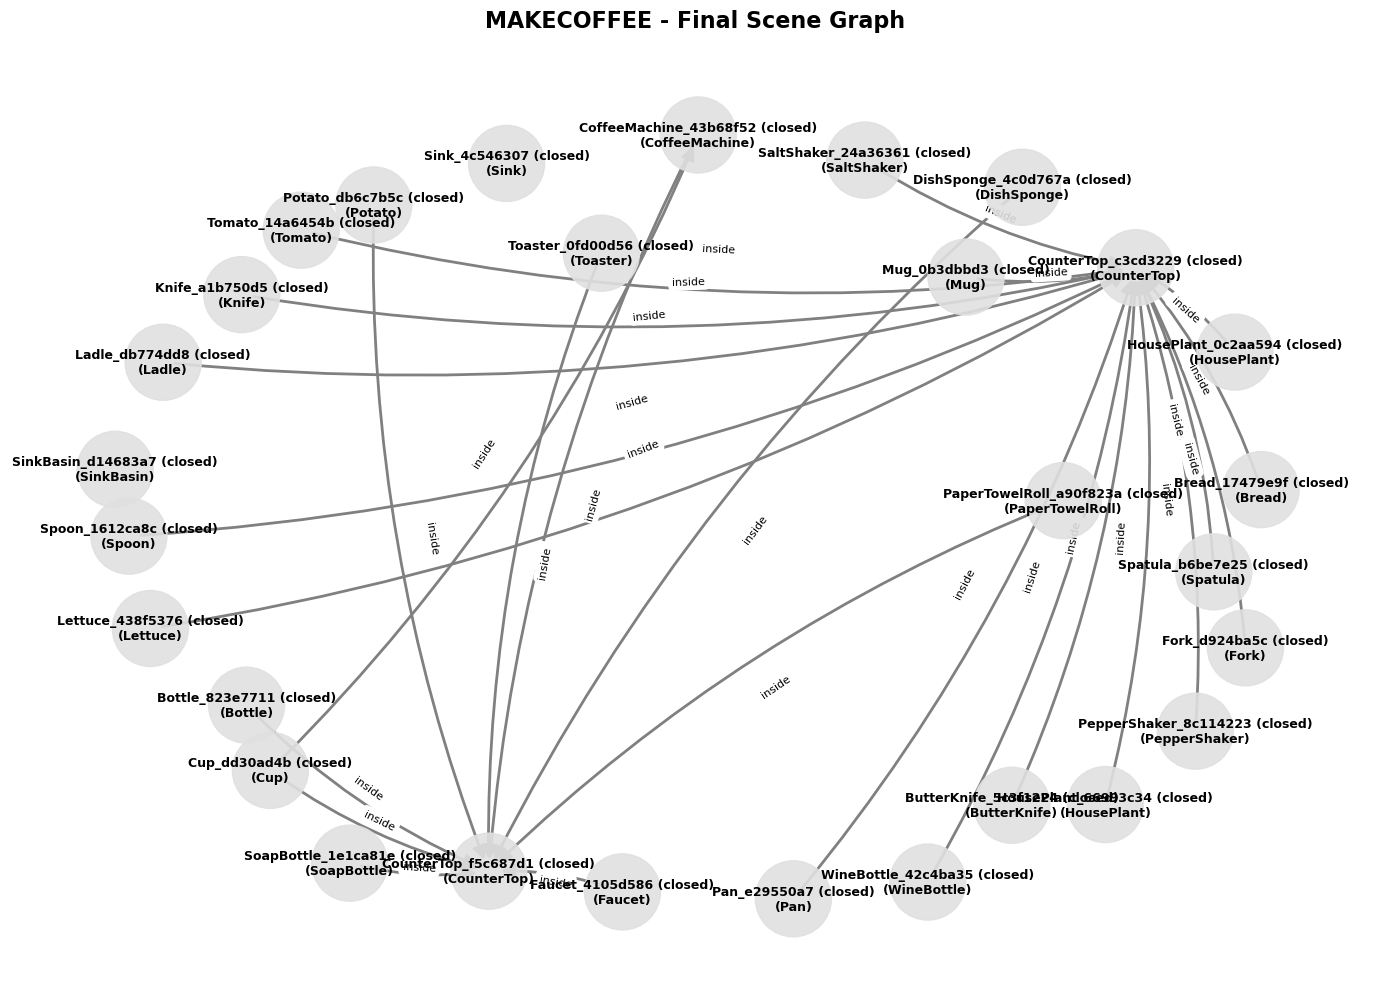


   节点详情:
      • CoffeeMachine_43b68f52 (CoffeeMachine, state=closed)
      • Spoon_1612ca8c (Spoon, state=closed)
      • CounterTop_c3cd3229 (CounterTop, state=closed)
      • Lettuce_438f5376 (Lettuce, state=closed)
      • WineBottle_42c4ba35 (WineBottle, state=closed)
      • Spatula_b6be7e25 (Spatula, state=closed)
      • Mug_0b3dbbd3 (Mug, state=closed)
      • DishSponge_4c0d767a (DishSponge, state=closed)
      • Cup_dd30ad4b (Cup, state=closed)
      • SoapBottle_1e1ca81e (SoapBottle, state=closed)
      ... 还有 19 个节点

   关系详情:
      • Bottle_823e7711 --[inside]--> CounterTop_f5c687d1
      • Bread_17479e9f --[inside]--> CounterTop_c3cd3229
      • ButterKnife_5c3f1224 --[inside]--> CounterTop_c3cd3229
      • CoffeeMachine_43b68f52 --[inside]--> CounterTop_f5c687d1
      • Cup_dd30ad4b --[inside]--> CoffeeMachine_43b68f52
      • Cup_dd30ad4b --[inside]--> CounterTop_f5c687d1
      • DishSponge_4c0d767a --[inside]--> CounterTop_f5c687d1
      • Faucet_4105d586 --[inside]--

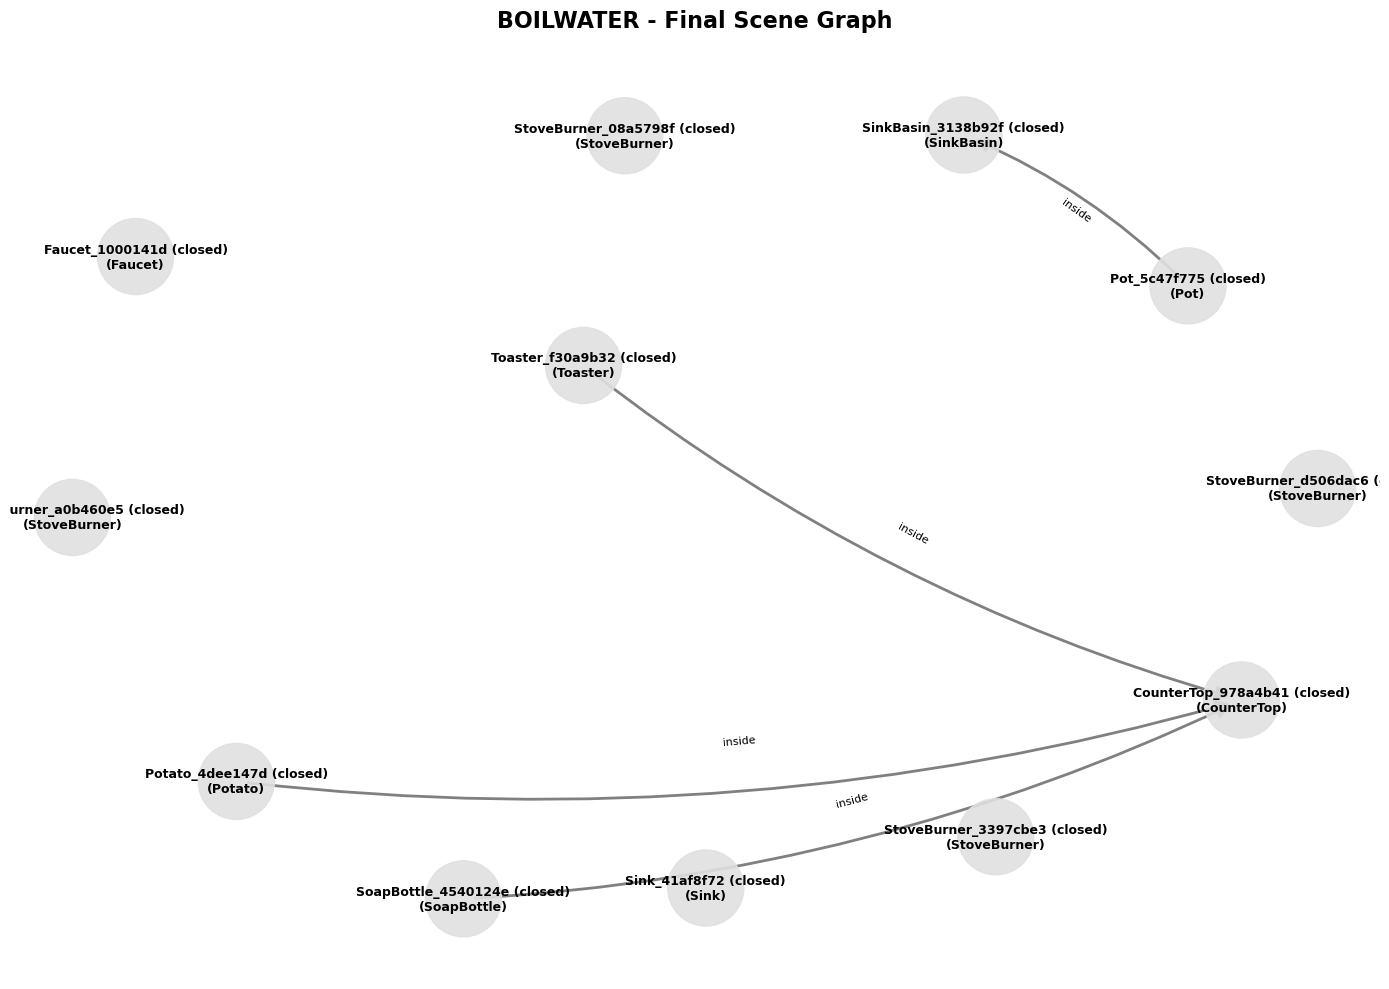


   节点详情:
      • StoveBurner_08a5798f (StoveBurner, state=closed)
      • CounterTop_978a4b41 (CounterTop, state=closed)
      • Pot_5c47f775 (Pot, state=closed)
      • Potato_4dee147d (Potato, state=closed)
      • StoveBurner_3397cbe3 (StoveBurner, state=closed)
      • SinkBasin_3138b92f (SinkBasin, state=closed)
      • Faucet_1000141d (Faucet, state=closed)
      • SoapBottle_4540124e (SoapBottle, state=closed)
      • Toaster_f30a9b32 (Toaster, state=closed)
      • StoveBurner_a0b460e5 (StoveBurner, state=closed)
      ... 还有 2 个节点

   关系详情:
      • Pot_5c47f775 --[inside]--> SinkBasin_3138b92f
      • Potato_4dee147d --[inside]--> CounterTop_978a4b41
      • SoapBottle_4540124e --[inside]--> CounterTop_978a4b41
      • Toaster_f30a9b32 --[inside]--> CounterTop_978a4b41

🔗 约束统计:
   总约束数: 7
     - precondition: 2
     - goal: 1
     - invariant: 4

   约束详情:

      1. [PRECONDITION]
         描述: Pot must be empty before filling with water
         条件表达式: (eq Pot_5c47f775.state '

In [40]:
# 结果可视化
print("="*80)
print("Step 6: 结果可视化")
print("="*80)
print()

# 导入可视化所需的库
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    VISUALIZATION_AVAILABLE = True
except ImportError:
    print("⚠️  networkx 或 matplotlib 不可用，将跳过图形可视化")
    VISUALIZATION_AVAILABLE = False

def visualize_scene_graph(scene_graph: SceneGraph, title: str = "Scene Graph"):
    """
    可视化场景图
    """
    if not VISUALIZATION_AVAILABLE:
        print(f"   ⚠️  无法可视化场景图（需要 networkx 和 matplotlib）")
        return
    
    G = nx.DiGraph()
    
    # 添加节点
    node_labels = {}
    for node in scene_graph.nodes:
        label = f"{node.get_name()}\n({node.object_type})"
        G.add_node(node.name, label=label, state=node.state)
        node_labels[node.name] = label
    
    # 添加边
    for (start_name, end_name), edge in scene_graph.edges.items():
        G.add_edge(start_name, end_name, label=edge.edge_type)
    
    # 创建布局
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # 绘制图形
    plt.figure(figsize=(14, 10))
    
    # 绘制节点 - 根据状态设置颜色
    node_colors = []
    for node_name in G.nodes():
        state = G.nodes[node_name].get('state') or ''
        if state and 'filled' in state.lower():
            node_colors.append('#90EE90')  # 浅绿色表示已填充
        elif state and 'empty' in state.lower():
            node_colors.append('#FFE5B4')  # 浅橙色表示空
        elif state and 'closed' in state.lower():
            node_colors.append('#E0E0E0')  # 灰色表示关闭
        elif state and 'open' in state.lower():
            node_colors.append('#87CEEB')  # 天蓝色表示打开
        else:
            node_colors.append('#B0E0E6')  # 浅蓝色表示其他
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=3000, alpha=0.9, node_shape='o')
    
    # 绘制节点标签
    nx.draw_networkx_labels(G, pos, labels=node_labels, 
                          font_size=9, font_weight='bold')
    
    # 绘制边
    edge_labels = {}
    for (start, end), edge_data in G.edges.items():
        edge_labels[(start, end)] = edge_data.get('label', '')
    
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                         arrows=True, arrowsize=20, 
                         connectionstyle='arc3,rad=0.1', width=2)
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

for task_name, data in task_data.items():
    print(f"{'='*80}")
    print(f"任务: {task_name.upper()}")
    print(f"{'='*80}")
    
    task_info = data.get('task_info', {})
    print(f"\n📋 任务信息:")
    print(f"   名称: {task_info.get('name', 'N/A')}")
    print(f"   场景: {task_info.get('scene', 'N/A')}")
    print(f"   动作数: {len(data.get('action_results', []))}")
    print(f"   成功条件: {task_info.get('success_condition', 'N/A')}")
    
    # 场景图统计和可视化
    if 'final_sg' in data:
        final_sg = data['final_sg']
        print(f"\n📊 场景图统计:")
        print(f"   节点数: {len(final_sg.nodes)}")
        print(f"   边数: {len(final_sg.edges)}")
        
        # 显示场景图文本描述
        print(f"\n   场景图文本描述:")
        print(f"   {final_sg.to_text()[:200]}...")
        
        # 可视化场景图
        print(f"\n   📈 场景图可视化:")
        visualize_scene_graph(final_sg, title=f"{task_name.upper()} - Final Scene Graph")
        
        # 详细节点信息
        print(f"\n   节点详情:")
        for node in list(final_sg.nodes)[:10]:  # 只显示前10个节点
            state_info = f", state={node.state}" if node.state else ""
            attrs = []
            if node.attributes:
                if node.attributes.get('isFilled'):
                    attrs.append("filled")
                if node.attributes.get('isOpen'):
                    attrs.append("open")
                if node.attributes.get('isToggled'):
                    attrs.append("toggled")
                if node.attributes.get('isPickedUp'):
                    attrs.append("pickedUp")
            attrs_str = f", attributes=[{', '.join(attrs)}]" if attrs else ""
            print(f"      • {node.name} ({node.object_type}{state_info}{attrs_str})")
        if len(final_sg.nodes) > 10:
            print(f"      ... 还有 {len(final_sg.nodes) - 10} 个节点")
        
        # 详细边信息
        if final_sg.edges:
            print(f"\n   关系详情:")
            for (start, end), edge in list(final_sg.edges.items())[:10]:  # 只显示前10条边
                print(f"      • {start} --[{edge.edge_type}]--> {end}")
            if len(final_sg.edges) > 10:
                print(f"      ... 还有 {len(final_sg.edges) - 10} 条关系")
    
    # 约束统计和详情
    if 'constraints' in data:
        constraints = data.get('constraints', [])
        print(f"\n🔗 约束统计:")
        print(f"   总约束数: {len(constraints)}")
        if constraints:
            constraint_types = {}
            for c in constraints:
                ctype = c.get('type', 'unknown')
                constraint_types[ctype] = constraint_types.get(ctype, 0) + 1
            for ctype, count in constraint_types.items():
                print(f"     - {ctype}: {count}")
        
        # 显示所有约束的详细信息
        if constraints:
            print(f"\n   约束详情:")
            for i, constraint in enumerate(constraints, 1):
                ctype = constraint.get('type', 'unknown')
                desc = constraint.get('description', 'N/A')
                print(f"\n      {i}. [{ctype.upper()}]")
                print(f"         描述: {desc}")
                if 'condition_expr' in constraint:
                    print(f"         条件表达式: {constraint['condition_expr']}")
                elif 'condition' in constraint:
                    print(f"         条件: {constraint['condition']}")
        
        # 显示编译后的约束代码
        if 'compiled_constraints' in data:
            compiled = data.get('compiled_constraints', [])
            print(f"\n   编译后的约束代码 (AST/DSL):")
            for i, comp_constraint in enumerate(compiled, 1):
                ctype = comp_constraint.get('type', 'unknown')
                condition_expr = comp_constraint.get('condition_expr', 'N/A')
                desc = comp_constraint.get('description', 'N/A')[:60]
                print(f"\n      {i}. [{ctype.upper()}] {desc}...")
                print(f"         可执行代码: {condition_expr}")
                print(f"         代码说明: 此代码将在场景图上执行以验证约束是否满足")
    
    # 检测结果详情
    if 'detection_results' in data:
        results = data['detection_results']
        print(f"\n🔍 失败检测结果:")
        print(f"   总约束数: {results['total_constraints']}")
        print(f"   违反数: {results['violation_count']}")
        print(f"   满足数: {len(results['satisfied'])}")
        print(f"   任务状态: {'❌ 失败' if results['violation_count'] > 0 else '✅ 成功'}")
        
        # 详细显示失败检测过程
        if 'compiled_constraints' in data and 'final_sg' in data:
            compiled = data.get('compiled_constraints', [])
            final_sg = data.get('final_sg')
            
            print(f"\n   失败检测过程详解:")
            print(f"   {'='*70}")
            print(f"   对每个约束，系统会:")
            print(f"   1. 从约束描述中提取相关对象名称")
            print(f"   2. 在场景图中查找对应的节点")
            print(f"   3. 执行编译后的约束代码（condition_expr）")
            print(f"   4. 检查返回结果是否为 True（满足）或 False（违反）")
            print(f"   {'='*70}")
            
            # 显示每个约束的检测详情
            print(f"\n   各约束检测详情:")
            for i, comp_constraint in enumerate(compiled, 1):
                is_violated = any(v['constraint'] == comp_constraint for v in results.get('violations', []))
                status = "❌ 违反" if is_violated else "✅ 满足"
                ctype = comp_constraint.get('type', 'unknown')
                desc = comp_constraint.get('description', 'N/A')
                condition_expr = comp_constraint.get('condition_expr', 'N/A')
                
                print(f"\n      {i}. [{ctype.upper()}] {status}")
                print(f"         约束描述: {desc}")
                print(f"         执行代码: {condition_expr}")
                if is_violated:
                    violation_info = next((v for v in results.get('violations', []) if v['constraint'] == comp_constraint), None)
                    if violation_info:
                        print(f"         违反原因: {violation_info.get('reason', 'N/A')}")
        
        # 显示违反的约束
        if results['violations']:
            print(f"\n   ⚠️  违反的约束详情:")
            for i, violation in enumerate(results['violations'], 1):
                constraint = violation['constraint']
                desc = constraint.get('description', 'N/A')
                condition_expr = constraint.get('condition_expr', 'N/A')
                reason = violation.get('reason', 'N/A')
                print(f"\n      {i}. [{constraint.get('type', 'unknown').upper()}]")
                print(f"         描述: {desc}")
                print(f"         执行代码: {condition_expr}")
                print(f"         违反原因: {reason}")
        else:
            print(f"\n   ✅ 所有约束都满足，任务执行成功！")
        
        # 显示满足的约束
        if results['satisfied']:
            print(f"\n   ✅ 满足的约束 ({len(results['satisfied'])} 个):")
            for i, constraint in enumerate(results['satisfied'][:5], 1):  # 只显示前5个
                desc = constraint.get('description', 'N/A')
                print(f"      {i}. {desc[:70]}...")
            if len(results['satisfied']) > 5:
                print(f"      ... 还有 {len(results['satisfied']) - 5} 个约束满足")
    
    print()

print("="*80)
print("✅ CRAFT 流程执行完成！")
print("="*80)
